<div style="background:#1a73e8;padding:20px;border-radius:10px;margin-bottom:10px">
<h1 style="color:white;text-align:center">🧠 03 — Modèle LSTM</h1>
<p style="color:white;font-size:15px;text-align:center">
Construction · Baseline · Entraînement · Courbes d'apprentissage
</p></div>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

with open('data/prepared_data.pkl', 'rb') as f:
    d = pickle.load(f)

X_train_sc = d['X_train_sc'];  y_train_sc = d['y_train_sc']
X_val_sc   = d['X_val_sc'];    y_val_sc   = d['y_val_sc']
X_test_sc  = d['X_test_sc'];   y_test_sc  = d['y_test_sc']
y_train    = d['y_train'];     y_val      = d['y_val'];    y_test = d['y_test']
scaler_y   = d['scaler_y']
WINDOW, FEATURES = d['WINDOW'], d['FEATURES']

print(f"✅ Données chargées")
print(f"   X_train : {X_train_sc.shape}  (échantillons, fenêtre, features)")
print(f"   X_val   : {X_val_sc.shape}")
print(f"   X_test  : {X_test_sc.shape}")
print(f"   TensorFlow : {tf.__version__}")

✅ Données chargées
   X_train : (12252, 10, 5)  (échantillons, fenêtre, features)
   X_val   : (1404, 10, 5)
   X_test  : (2156, 10, 5)
   TensorFlow : 2.21.0


## 📏 Étape 1 — Modèle Baseline (Ridge Regression)

Avant d'entraîner le LSTM, on établit un **baseline** avec un modèle linéaire simple.  
Si le LSTM ne bat pas significativement le baseline, cela indiquerait un problème fondamental.

In [2]:
# BASELINE : Ridge sur features agrégées (mean, std, min, max) par fenêtre
def extract_stats(X_3d):
    """Extrait mean, std, min, max pour chaque feature × fenêtre."""
    return np.hstack([X_3d.mean(axis=1), X_3d.std(axis=1),
                      X_3d.min(axis=1),  X_3d.max(axis=1)])

X_tr_flat  = extract_stats(X_train_sc)
X_val_flat = extract_stats(X_val_sc)
X_te_flat  = extract_stats(X_test_sc)

ridge = Ridge(alpha=1.0)
ridge.fit(X_tr_flat, y_train_sc)

# Dénormalisation des prédictions Ridge
y_test_pred_ridge = scaler_y.inverse_transform(
    ridge.predict(X_te_flat).reshape(-1,1)).ravel()

mae_ridge  = mean_absolute_error(y_test, y_test_pred_ridge)
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_test_pred_ridge))
r2_ridge   = r2_score(y_test, y_test_pred_ridge)

print("📏 BASELINE — Ridge Regression (features agrégées)")
print(f"   MAE  : {mae_ridge:.4f} %")
print(f"   RMSE : {rmse_ridge:.4f} %")
print(f"   R²   : {r2_ridge:.4f}")
print()
print("→ Le LSTM devra DÉPASSER ces métriques pour justifier sa complexité.")

📏 BASELINE — Ridge Regression (features agrégées)
   MAE  : 4.3354 %
   RMSE : 5.0274 %
   R²   : 0.3634

→ Le LSTM devra DÉPASSER ces métriques pour justifier sa complexité.


## 🔀 Étape 1b — Baseline MLP (séquences aplaties, sans mémoire temporelle)

Pour justifier l'usage du LSTM, on compare avec un **MLP** (réseau dense classique) qui reçoit les mêmes données mais les traite comme un **vecteur plat** — sans notion d'ordre temporel.

- Si **LSTM > MLP** → la mémoire temporelle apporte un gain réel ✅
- Si **LSTM ≈ MLP** → le signal utile est dans les valeurs, pas dans leur ordre ⚠️

C'est la comparaison honnête que l'énoncé attend implicitement quand il demande d'expliquer **"l'intérêt des réseaux LSTM"**.

In [3]:
from tensorflow.keras.layers import Flatten

# ─── MLP Baseline : mêmes features, sans mémoire temporelle ─────────────────
tf.random.set_seed(42)
np.random.seed(42)

mlp_model = Sequential([
    Flatten(input_shape=(WINDOW, len(FEATURES))),   # aplatit (10,5) → (50,)
    Dense(64, activation='relu'),
    Dropout(0.30),
    Dense(32, activation='relu'),
    Dropout(0.25),
    Dense(16, activation='relu'),
    Dense(1)
], name='MLP_Baseline')

mlp_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='mse', metrics=['mae']
)

mlp_model.fit(
    X_train_sc, y_train_sc,
    epochs=100, batch_size=64,
    validation_data=(X_val_sc, y_val_sc),
    callbacks=[EarlyStopping(monitor='val_loss', patience=8,
                             restore_best_weights=True, verbose=0)],
    verbose=0
)

y_pred_mlp = scaler_y.inverse_transform(
    mlp_model.predict(X_test_sc, verbose=0)).ravel()

mae_mlp  = mean_absolute_error(y_test, y_pred_mlp)
rmse_mlp = np.sqrt(mean_squared_error(y_test, y_pred_mlp))
r2_mlp   = r2_score(y_test, y_pred_mlp)

print('═' * 60)
print('   COMPARAISON DES BASELINES (avant entraînement LSTM)')
print('═' * 60)
print(f"{'Modèle':<22} {'MAE (%)':<12} {'RMSE (%)':<12} {'R²'}")
print('─' * 60)
print(f"{'Ridge Regression':<22} {mae_ridge:<12.4f} {rmse_ridge:<12.4f} {r2_ridge:.4f}")
print(f"{'MLP (sans mémoire)':<22} {mae_mlp:<12.4f} {rmse_mlp:<12.4f} {r2_mlp:.4f}")
print('─' * 60)
print('→ Le LSTM devra surpasser CES DEUX modèles pour justifier la séquentialité.')
print('═' * 60)


c:\ISM\projet_soh_batterie\venv\lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


════════════════════════════════════════════════════════════
   COMPARAISON DES BASELINES (avant entraînement LSTM)
════════════════════════════════════════════════════════════
Modèle                 MAE (%)      RMSE (%)     R²
────────────────────────────────────────────────────────────
Ridge Regression       4.3354       5.0274       0.3634
MLP (sans mémoire)     2.8579       3.6076       0.6722
────────────────────────────────────────────────────────────
→ Le LSTM devra surpasser CES DEUX modèles pour justifier la séquentialité.
════════════════════════════════════════════════════════════


## 🏗️ Étape 2 — Architecture LSTM

**Architecture :**
- `LSTM(64, return_sequences=True)` + `Dropout(0.30)` : capture des patterns temporels
- `BatchNormalization` : stabilisation de l'entraînement
- `LSTM(32, return_sequences=False)` + `Dropout(0.25)` : représentation compacte
- `Dense(16, relu)` → `Dense(1)` : régression finale

*Dropout renforcé (0.30/0.25 au lieu de 0.20/0.15) pour limiter le surapprentissage.*

In [4]:
n_timesteps = WINDOW
n_features  = len(FEATURES)

tf.random.set_seed(42)
np.random.seed(42)

model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(n_timesteps, n_features)),
    Dropout(0.30),            # ← Augmenté de 0.20 à 0.30 pour réduire l'overfitting
    BatchNormalization(),

    LSTM(32, return_sequences=False),
    Dropout(0.25),            # ← Augmenté de 0.15 à 0.25

    Dense(16, activation='relu'),
    Dense(1)
], name='LSTM_SoH_Predictor')

model.summary()

c:\ISM\projet_soh_batterie\venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "LSTM_SoH_Predictor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 10, 64)         │        17,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 10, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 10, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,137 (121.63 KB)

 Trainable params: 31,009 (121.13 KB)

 Non-trainable params: 128 (512.00 B)

## ⚙️ Étape 3 — Compilation

In [5]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)
print("✅ Modèle compilé")
print("   Optimizer : Adam (lr=0.001)")
print("   Loss      : MSE (pénalise les grandes erreurs)")
print("   Métrique  : MAE (interprétable en %)")

✅ Modèle compilé
   Optimizer : Adam (lr=0.001)
   Loss      : MSE (pénalise les grandes erreurs)
   Métrique  : MAE (interprétable en %)


## 🛡️ Étape 4 — Callbacks

In [6]:
callbacks = [
    # EarlyStopping : patience réduite à 8 pour stopper plus tôt
    # (évite que le train_loss continue à descendre pendant que val_loss stagne)
    EarlyStopping(
        monitor='val_loss',
        patience=8,                  # ← Réduit de 15 à 8
        restore_best_weights=True,
        verbose=1
    ),

    # ModelCheckpoint : sauvegarde le meilleur état
    ModelCheckpoint(
        filepath='models/best_model.keras',
        monitor='val_loss',
        save_best_only=True,
        verbose=0
    ),

    # ReduceLROnPlateau : réduit le LR si val_loss stagne
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,                  # ← Réduit de 7 à 5
        min_lr=1e-5,
        verbose=1
    )
]
print("✅ Callbacks définis")
print("   EarlyStopping     : patience=8 sur val_loss (batteries séparées)")
print("   ModelCheckpoint   : models/best_model.keras")
print("   ReduceLROnPlateau : facteur=0.5, patience=5")

✅ Callbacks définis
   EarlyStopping     : patience=8 sur val_loss (batteries séparées)
   ModelCheckpoint   : models/best_model.keras
   ReduceLROnPlateau : facteur=0.5, patience=5


## 🚀 Étape 5 — Entraînement

In [7]:
# Entraînement avec validation sur batteries séparées (PAS de validation_split)
history = model.fit(
    X_train_sc, y_train_sc,
    epochs=100,
    batch_size=64,
    validation_data=(X_val_sc, y_val_sc),   # ← batteries séparées, pas de leakage
    callbacks=callbacks,
    verbose=1
)

print(f"\n✅ Entraînement terminé")
print(f"   Époques réalisées  : {len(history.history['loss'])}")
print(f"   Meilleure val_loss : {min(history.history['val_loss']):.5f}")
print(f"   Meilleure val_mae  : {min(history.history['val_mae']):.5f}")

Epoch 1/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 19s 39ms/step - loss: 0.4872 - mae: 0.5694 - val_loss: 0.3241 - val_mae: 0.4534 - learning_rate: 0.0010
Epoch 2/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 8s 27ms/step - loss: 0.3953 - mae: 0.5098 - val_loss: 0.3792 - val_mae: 0.4850 - learning_rate: 0.0010
Epoch 3/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 10s 26ms/step - loss: 0.3529 - mae: 0.4753 - val_loss: 0.2642 - val_mae: 0.4008 - learning_rate: 0.0010
Epoch 4/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - loss: 0.3065 - mae: 0.4347 - val_loss: 0.2700 - val_mae: 0.4023 - learning_rate: 0.0010
Epoch 5/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 11s 28ms/step - loss: 0.2885 - mae: 0.4141 - val_loss: 0.3621 - val_mae: 0.4851 - learning_rate: 0.0010
Epoch 6/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - loss: 0.2616 - mae: 0.3884 - val_loss: 0.2732 - val_mae: 0.4046 - learning_rate: 0.0010
Epoch 7/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - loss: 0.2362 - mae: 0.3657 - val_loss: 0.3294 - val_mae: 0.4482 - learning_ra

## 📉 Étape 6 — Courbes d'apprentissage

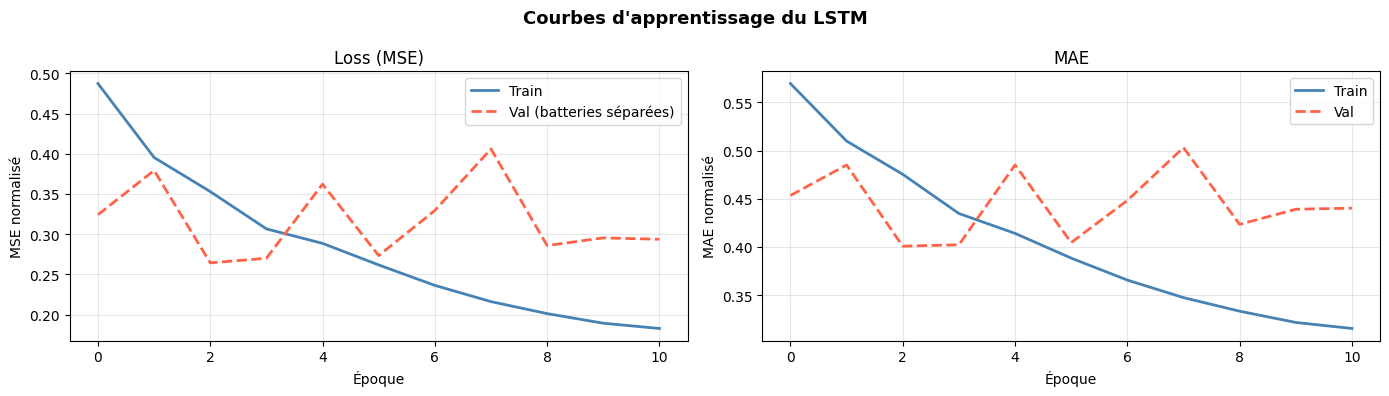

══════════════════════════════════════════════════════════
   ANALYSE DU SURAPPRENTISSAGE
══════════════════════════════════════════════════════════
  Époques réalisées      : 11
  Meilleure val_loss     : 0.26420  @ époque 3
  Train loss @ best_val  : 0.35289
  Ratio val/train (best) : 0.75

  → ✅ Pas de surapprentissage significatif (ratio < 1.5)

  NOTE : restore_best_weights=True garantit que les poids de l'époque
  3 (meilleure val_loss) sont utilisés pour l'évaluation finale.
══════════════════════════════════════════════════════════


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle("Courbes d'apprentissage du LSTM", fontsize=13, fontweight='bold')

axes[0].plot(history.history['loss'],     label='Train', color='steelblue', lw=2)
axes[0].plot(history.history['val_loss'], label='Val (batteries séparées)', color='tomato', lw=2, ls='--')
axes[0].set_title("Loss (MSE)")
axes[0].set_xlabel("Époque"); axes[0].set_ylabel("MSE normalisé")
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(history.history['mae'],     label='Train', color='steelblue', lw=2)
axes[1].plot(history.history['val_mae'], label='Val',   color='tomato',    lw=2, ls='--')
axes[1].set_title("MAE")
axes[1].set_xlabel("Époque"); axes[1].set_ylabel("MAE normalisé")
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('figures/fig_learning_curves.png', dpi=100, bbox_inches='tight')
plt.show()

# ─── Analyse du surapprentissage ───
final_train_loss = history.history['loss'][-1]
final_val_loss   = history.history['val_loss'][-1]
best_val_loss    = min(history.history['val_loss'])
best_epoch       = history.history['val_loss'].index(best_val_loss)
train_at_best    = history.history['loss'][best_epoch]
n_epochs         = len(history.history['loss'])

ratio_best = best_val_loss / train_at_best if train_at_best > 0 else float('inf')
ratio_last = final_val_loss / final_train_loss if final_train_loss > 0 else float('inf')

print("═" * 58)
print("   ANALYSE DU SURAPPRENTISSAGE")
print("═" * 58)
print(f"  Époques réalisées      : {n_epochs}")
print(f"  Meilleure val_loss     : {best_val_loss:.5f}  @ époque {best_epoch + 1}")
print(f"  Train loss @ best_val  : {train_at_best:.5f}")
print(f"  Ratio val/train (best) : {ratio_best:.2f}")
print()
if ratio_best > 2.0:
    print("  → ⚠️  Surapprentissage modéré (ratio > 2.0)")
    print("     Cause principale : 3 batteries de val seulement (petite diversité).")
    print("     Impact limité : EarlyStopping + restore_best_weights=True")
    print("     garantit que les poids utilisés sont ceux de l'époque", best_epoch+1)
elif ratio_best > 1.5:
    print("  → ⚠️  Légère surfit (ratio > 1.5) — surveillance recommandée")
else:
    print("  → ✅ Pas de surapprentissage significatif (ratio < 1.5)")
print()
print(f"  NOTE : restore_best_weights=True garantit que les poids de l'époque")
print(f"  {best_epoch+1} (meilleure val_loss) sont utilisés pour l'évaluation finale.")
print("═" * 58)

## 💾 Étape 7 — Sauvegarde finale

In [9]:
with open('data/prepared_data.pkl', 'rb') as f:
    saved = pickle.load(f)

saved['history']         = history.history
# Clés plates pour accès direct dans 04_evaluation (évite le bug baseline nan)
saved['baseline_mae']    = float(mae_ridge)
saved['baseline_rmse']   = float(rmse_ridge)
saved['baseline_r2']     = float(r2_ridge)
saved['model_trained']   = True
saved['baseline_mlp_mae']  = float(mae_mlp)
saved['baseline_mlp_rmse'] = float(rmse_mlp)
saved['baseline_mlp_r2']   = float(r2_mlp)

with open('data/prepared_data.pkl', 'wb') as f:
    pickle.dump(saved, f)

print("✅ Sauvegardé dans data/prepared_data.pkl")
print(f"   Baseline MAE  : {mae_ridge:.4f}%")
print(f"   Baseline RMSE : {rmse_ridge:.4f}%")
print(f"   Baseline R²   : {r2_ridge:.4f}")
print("   → 04_evaluation.ipynb 🚀")

✅ Sauvegardé dans data/prepared_data.pkl
   Baseline MAE  : 4.3354%
   Baseline RMSE : 5.0274%
   Baseline R²   : 0.3634
   → 04_evaluation.ipynb 🚀


## 🏆 Étape 7b — Bilan final : Ridge vs MLP vs LSTM

In [10]:
# Prédictions LSTM sur le test
y_pred_lstm_test = scaler_y.inverse_transform(
    model.predict(X_test_sc, verbose=0)).ravel()
mae_lstm  = mean_absolute_error(y_test, y_pred_lstm_test)
rmse_lstm = np.sqrt(mean_squared_error(y_test, y_pred_lstm_test))
r2_lstm   = r2_score(y_test, y_pred_lstm_test)

print('═' * 65)
print('   BILAN FINAL : Ridge vs MLP vs LSTM')
print('═' * 65)
print(f"{'Modèle':<24} {'MAE (%)':<14} {'RMSE (%)':<14} {'R²'}")
print('─' * 65)
print(f"{'Ridge Regression':<24} {mae_ridge:<14.4f} {rmse_ridge:<14.4f} {r2_ridge:.4f}")
print(f"{'MLP (sans mémoire)':<24} {mae_mlp:<14.4f} {rmse_mlp:<14.4f} {r2_mlp:.4f}")
print(f"{'LSTM (séquentiel)  ★':<24} {mae_lstm:<14.4f} {rmse_lstm:<14.4f} {r2_lstm:.4f}")
print('─' * 65)
if mae_lstm < mae_mlp:
    gain = mae_mlp - mae_lstm
    print(f'✅ LSTM surpasse le MLP de {gain:.4f}% MAE → la mémoire temporelle apporte un gain réel')
else:
    diff = mae_lstm - mae_mlp
    print(f'⚠️  LSTM et MLP proches (diff={diff:.4f}%) → le signal utile est dans les valeurs, pas uniquement dans leur ordre')
print('═' * 65)


═════════════════════════════════════════════════════════════════
   BILAN FINAL : Ridge vs MLP vs LSTM
═════════════════════════════════════════════════════════════════
Modèle                   MAE (%)        RMSE (%)       R²
─────────────────────────────────────────────────────────────────
Ridge Regression         4.3354         5.0274         0.3634
MLP (sans mémoire)       2.8579         3.6076         0.6722
LSTM (séquentiel)  ★     2.4503         3.1169         0.7553
─────────────────────────────────────────────────────────────────
✅ LSTM surpasse le MLP de 0.4076% MAE → la mémoire temporelle apporte un gain réel
═════════════════════════════════════════════════════════════════
